In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import modules.plots as mplts
import modules.style as ss

from sklearn.datasets import (
    load_iris, 
    load_digits, 
    load_breast_cancer
)
from sklearn.svm import SVC
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    RandomizedSearchCV,
    HalvingGridSearchCV,
    StratifiedKFold, 
    cross_val_score
)
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform
from modules.utils import is_representative_sample
from modules.model_selection import CoarseToFineSearchCV

%matplotlib inline

## 3. Подбор гиперпараметров

Гиперпараметры (например, `C` и `gamma` у `SVC`, глубина дерева,
число соседей у kNN) нельзя подобрать через `fit` — их нужно задавать
заранее и выбирать по качеству модели на данных, которые не
участвовали в обучении. Разберём несколько подходов — от наивного до
более продвинутых.

### 3.1 Наивный перебор (без кросс-валидации)

Самый простой (и самый ошибочный, если делать в лоб) вариант: для
каждой комбинации гиперпараметров обучить модель на train и
сразу оценить на test, выбрав комбинацию с лучшим результатом на test.

**Проблема:** тестовая выборка при этом используется многократно —
для *выбора* модели, а не только для её итоговой оценки. В результате
финальная оценка качества на test оказывается слишком оптимистичной:
мы, по сути, подобрали гиперпараметры "под" эту конкретную тестовую
выборку (утечка информации, аналог переобучения, но на этапе выбора
модели, а не обучения весов).

In [2]:
iris = load_iris()
digits = load_digits()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0)

best_score = 0
best_params = {}
for gamma in [0.001, 0.01, 0.1, 1, 10]:
    for C in [0.001, 0.01, 0.1, 1, 10]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)   # !!! оцениваем на тестовой выборке
        if score > best_score:
            best_score = score
            best_params = {"C": C, "gamma": gamma}

print("Наивный перебор — лучший результат на test: {:.3f}".format(best_score))
print("Лучшие параметры:", best_params)
print("ВНИМАНИЕ: это оптимистично смещённая оценка — test использовался для выбора C, gamma")

Наивный перебор — лучший результат на test: 0.974
Лучшие параметры: {'C': 10, 'gamma': 0.01}
ВНИМАНИЕ: это оптимистично смещённая оценка — test использовался для выбора C, gamma


Правильный подход — использовать для подбора гиперпараметров
**отдельную** от финального теста выборку: либо явную
валидационную выборку (трёхстороннее разбиение train/validation/test),
либо (что надёжнее и экономнее по данным) — кросс-валидацию внутри
обучающей выборки.

### 3.2 Решётчатый поиск с перекрёстной проверкой (`GridSearchCV`)

Идея: полностью перебрать все комбинации значений гиперпараметров
из заданной "решётки" (`param_grid`), но для оценки качества *каждой*
комбинации использовать не один validation-сплит, а полноценную
кросс-валидацию на обучающей выборке. Тестовая выборка при этом
остаётся полностью "нетронутой" до самого конца и используется только
один раз — для финальной, честной оценки уже выбранной модели.

**Параметры `GridSearchCV`:** `estimator`, `param_grid` (словарь или
список словарей "имя параметра → список значений"), `scoring`, `cv`,
`n_jobs`, `refit` (переобучить ли лучшую модель на всей обучающей
выборке, по умолчанию `True`), `return_train_score`, `verbose`.

**Плюсы:**
* гарантированно находит лучшую комбинацию *в пределах заданной
  решётки* — исчерпывающий перебор;
* качество каждой комбинации оценивается по кросс-валидации, а не по
  одному разбиению — оценка устойчивее;
* после `fit` доступны `best_params_`, `best_score_`, `best_estimator_`,
  подробная таблица `cv_results_`.

**Минусы (ограничения):**
* **комбинаторный взрыв**: время работы растёт экспоненциально с
  числом гиперпараметров и линейно с плотностью решётки по каждому —
  для многомерных пространств становится практически неприменим;
* решётка задаётся вручную — если диапазон значений выбран неудачно
  (слишком узко/широко/грубо), можно пропустить хороший регион;
* при большом числе комбинаций и маленьком `cv` есть риск
  переобучиться уже *на кросс-валидационные блоки* (validation set
  overfitting) — для честной финальной оценки качества в этом случае
  стоит использовать вложенную кросс-валидацию (см. 3.5).

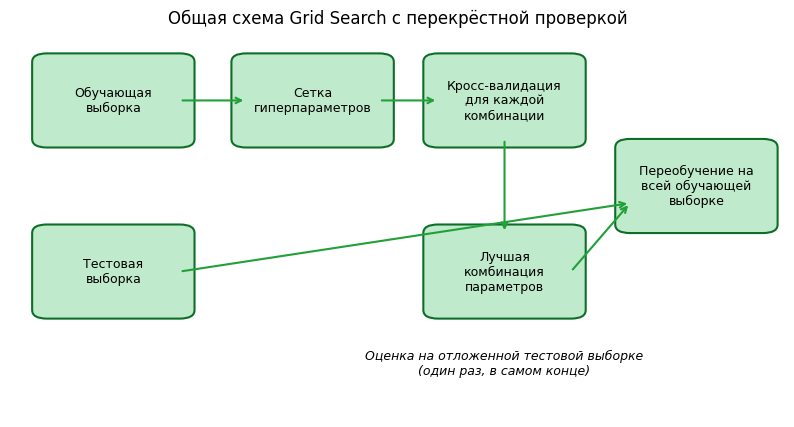

In [3]:
mplts.plot_grid_search_overview()
plt.show()

In [4]:
param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
              "gamma": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(SVC(), param_grid=param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая cv-правильность: {:.3f}".format(grid_search.best_score_))
print("Правильность на тестовой выборке: {:.3f}".format(grid_search.score(X_test, y_test)))

Лучшие параметры: {'C': 10, 'gamma': 0.1}
Лучшая cv-правильность: 0.973
Правильность на тестовой выборке: 0.974


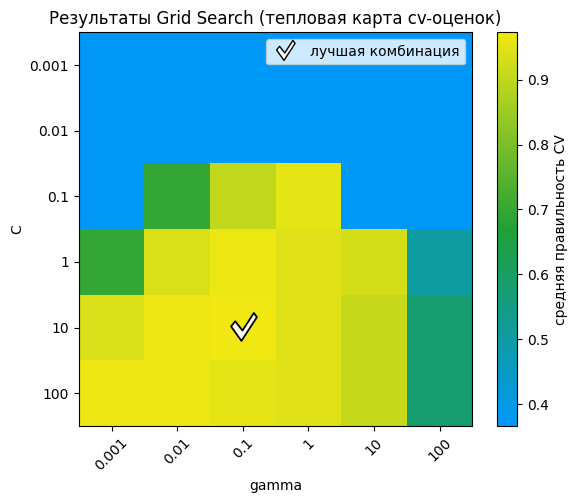

In [5]:
results = pd.DataFrame(grid_search.cv_results_)
scores_grid = np.array(results.mean_test_score).reshape(6, 6)

c_values = param_grid["C"]
gamma_values = param_grid["gamma"]
best_flat_idx = np.argmax(scores_grid)
best_idx = np.unravel_index(best_flat_idx, scores_grid.shape)

mplts.plot_cross_val_selection(
    scores_grid, "C", c_values,
    "gamma", gamma_values,
    best_idx=best_idx
)
plt.show()

### 3.3 Случайный поиск (`RandomizedSearchCV`)

Вместо полного перебора решётки, на каждой итерации случайным образом
сэмплируется `n_iter` комбинаций гиперпараметров — либо из списков
значений, либо из статистических распределений (`scipy.stats`),
что позволяет задавать непрерывные диапазоны, а не дискретную сетку.

**Параметры:** `estimator`, `param_distributions` (словарь "имя
параметра → список значений или распределение с методом `.rvs()`"),
`n_iter` (число случайных комбинаций), `scoring`, `cv`, `random_state`,
`n_jobs`.

**Плюсы:**
* существенно быстрее исчерпывающего перебора при большом числе
  гиперпараметров — вычислительный бюджет (`n_iter`) задаётся
  напрямую, независимо от размерности пространства;
* по результатам эмпирических исследований (Bergstra & Bengio, 2012),
  при большом числе гиперпараметров случайный поиск часто находит
  сопоставимое по качеству решение за то же время, что и решётчатый —
  потому что не тратит бюджет на равномерный перебор *неважных*
  параметров;
* позволяет задавать непрерывные распределения (например,
  логарифмически равномерное для `C`/`gamma`), а не только
  фиксированный дискретный список значений.

**Минусы (ограничения):**
* не исчерпывающий — не гарантирует нахождение оптимума даже в
  пределах заданных диапазонов, результат зависит от `random_state`;
* нужно заранее выбрать `n_iter` — при слишком малом значении можно
  не успеть обследовать пространство;
* для дискретных/категориальных параметров с малым числом значений
  выгода по сравнению с Grid Search обычно меньше.

In [6]:
param_distributions = {"C": loguniform(1e-3, 1e2), "gamma": loguniform(1e-3, 1e2)}

random_search = RandomizedSearchCV(SVC(), param_distributions=param_distributions,
                                    n_iter=25, cv=5, random_state=0)
random_search.fit(X_train, y_train)

print("Лучшие параметры:", random_search.best_params_)
print("Лучшая cv-правильность: {:.3f}".format(random_search.best_score_))
print("Правильность на тестовой выборке: {:.3f}".format(random_search.score(X_test, y_test)))
print("Число обученных комбинаций: {} (вместо {} у полной решётки 6x6)".format(
    len(random_search.cv_results_["params"]), 36)
)

Лучшие параметры: {'C': np.float64(9.091283280651457), 'gamma': np.float64(0.44103656679709863)}
Лучшая cv-правильность: 0.973
Правильность на тестовой выборке: 0.974
Число обученных комбинаций: 25 (вместо 36 у полной решётки 6x6)


### 3.4 Successive Halving (`HalvingGridSearchCV` / `HalvingRandomSearchCV`)

Более "продвинутый" вариант перебора: поиск начинается с большого
числа кандидатов (комбинаций гиперпараметров), которые оцениваются на
*небольшом* подмножестве обучающих данных (или с небольшим числом
итераций/деревьев и т.п.); затем худшая половина кандидатов
отбрасывается, а оставшиеся оцениваются уже на большем объёме
ресурсов. Процесс повторяется, пока не останется несколько лучших
кандидатов, оценённых на полном датасете.

**Параметры (основные):** `estimator`, `param_grid`/`param_distributions`,
`factor` (во сколько раз сокращается число кандидатов и увеличивается
объём ресурсов на каждой итерации, по умолчанию 3), `resource`
(что наращивается — обычно `"n_samples"`), `min_resources`,
`cv`.

**Плюсы:**
* существенно быстрее полного Grid/Randomized Search при большом числе
  кандидатов — заведомо слабые комбинации отсеиваются рано, не тратя
  вычисления на их полную оценку;
* хорошо сочетается и с решётчатым, и со случайным поиском (есть обе
  вариации).

**Минусы (ограничения):**
* по состоянию на многие версии scikit-learn API остаётся
  экспериментальным (требует `from sklearn.experimental import
  enable_halving_search_cv`) и может меняться;
* оценка на малом подмножестве данных на ранних итерациях — более
  шумная, из-за чего действительно хорошая комбинация может быть
  отброшена слишком рано просто "не повезло" на маленькой подвыборке;
* не для всех моделей ресурс "число примеров" одинаково хорошо
  коррелирует с качеством на полном датасете.

In [7]:
halving_search = HalvingGridSearchCV(SVC(), param_grid=param_grid, cv=5,
                                      factor=3, random_state=0)
halving_search.fit(X_train, y_train)

print("Лучшие параметры:", halving_search.best_params_)
print("Лучшая cv-правильность: {:.3f}".format(halving_search.best_score_))
print("Правильность на тестовой выборке: {:.3f}".format(halving_search.score(X_test, y_test)))
print("Число итераций halving:", halving_search.n_iterations_)

Лучшие параметры: {'C': 1, 'gamma': 0.1}
Лучшая cv-правильность: 0.954
Правильность на тестовой выборке: 0.974
Число итераций halving: 2


### 3.5 Вложенная кросс-валидация (nested cross-validation)

Если использовать один и тот же `cv` и для подбора гиперпараметров, и
для финальной оценки качества (`grid_search.best_score_`), эта оценка
может быть немного оптимистично смещена — ведь мы выбрали лучшую
комбинацию именно по этим блокам. Чтобы получить полностью честную,
не смещённую оценку обобщающей способности **всего процесса**
"подбор гиперпараметров + обучение", используют вложенную (nested)
кросс-валидацию: внешний цикл CV оценивает качество, а внутри каждого
внешнего блока запускается свой независимый `GridSearchCV` (внутренний
цикл CV) только на данных внешнего train.

**Плюсы:**
* даёт несмещённую оценку качества всего пайплайна выбора модели,
  пригодную, например, для честного сравнения нескольких алгоритмов
  между собой;
* явно показывает разброс итогового качества (можно посчитать std по
  внешним блокам).

**Минусы (ограничения):**
* дорого: если внешний cv — 5 блоков, а внутренний Grid Search
  перебирает 36 комбинаций с cv=5, модель обучается `5 * 36 * 5 = 900`
  раз;
* на выходе получаем **оценку качества метода**, а не единый набор
  гиперпараметров для последующего использования в продакшене — для
  этого отдельно запускают `GridSearchCV` уже на всех данных.

In [8]:
inner_cv = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
nested_scores = cross_val_score(inner_cv, iris.data, iris.target, cv=5)

print("Оценки вложенной CV по внешним блокам:", np.round(nested_scores, 3))
print("Среднее (несмещённая оценка): {:.3f} +- {:.3f}".format(
    nested_scores.mean(), nested_scores.std()))

Оценки вложенной CV по внешним блокам: [0.967 1.    0.967 0.967 1.   ]
Среднее (несмещённая оценка): 0.980 +- 0.016


## 4. Как проверить, репрезентативна ли выборка

Кросс-валидация и подбор гиперпараметров опираются на важное
предположение: обучающая и тестовая (или обучающая и "боевая",
production) выборки взяты из **одного и того же распределения**. Если
это не так — например, тестовые данные собраны в другое время, из
другого источника, после изменения бизнес-процесса — то даже самая
аккуратная кросс-валидация не спасёт от того, что модель на новых
данных будет работать хуже, чем показывает валидация.

**Идея проверки (adversarial validation):**

1. Помечаем все объекты `train` меткой `0`, все объекты `test` —
   меткой `1`.
2. Объединяем оба набора в один датасет (используя только признаки, **без**
   целевой переменной).
3. Обучаем классификатор, задача которого — отличить, откуда пришёл
   объект: из `train` или из `test`. Качество классификатора оцениваем
   с помощью кросс-валидации по метрике ROC AUC.
4. Интерпретация:
   * Если классификатору **не удаётся** уверенно отличить train от
     test (AUC ≈ 0.5, как случайное угадывание) — значит, по
     распределению признаков они неразличимы, и выборка
     **репрезентативна**.
   * Если классификатор **легко** отличает train от test (AUC близко
     к 1.0) — значит, распределения признаков заметно отличаются
     (data drift, разные источники данных и т.п.), и выборка
     **нерепрезентативна**. При этом `feature_importances_` такого
     классификатора подсказывают, *какие именно* признаки сильнее
     всего "выдают" происхождение объекта — с них и стоит начинать
     разбор проблемы.

**Сценарий A — репрезентативная выборка.** Обычный случайный
`train_test_split` на одном и том же датасете: train и test взяты из
одного распределения.

In [9]:
data = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(data.data, data.target,
                                           test_size=0.3, random_state=0)

result_a = is_representative_sample(X_tr, X_te)

Adversarial validation ROC AUC: 0.476 (+- 0.062)
Порог: 0.60  ->  Выборка: РЕПРЕЗЕНТАТИВНА
Классификатор не может уверенно отличить train от test — распределения признаков похожи.


**Сценарий B — нерепрезентативная выборка.** Искусственно создадим
сдвиг распределения (covariate shift): отсортируем данные по одному из
признаков и возьмём как train — объекты с "маленькими" значениями
этого признака, а как test — с "большими". Это имитирует, например,
ситуацию, когда тестовые данные собраны позже и параметры процесса
измерения сместились.

Adversarial validation ROC AUC: 1.000 (+- 0.000)
Порог: 0.60  ->  Выборка: НЕ репрезентативна
Классификатор уверенно отличает train от test — распределения признаков различаются (возможен data drift).


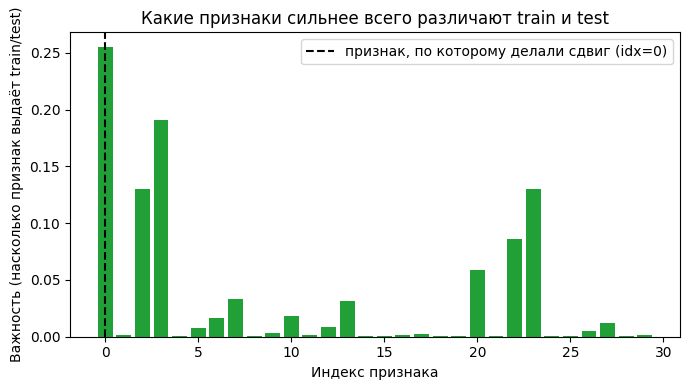

In [10]:
feature_idx = 0  # 'mean radius'
order = np.argsort(data.data[:, feature_idx])
split_point = int(0.7 * len(order))
train_idx, test_idx = order[:split_point], order[split_point:]

X_tr_shift, X_te_shift = data.data[train_idx], data.data[test_idx]

result_b = is_representative_sample(X_tr_shift, X_te_shift)

plt.figure(figsize=(7, 4))
plt.bar(range(len(result_b["feature_importances"])), result_b["feature_importances"],
        color=ss.GREEN)
plt.xlabel("Индекс признака")
plt.ylabel("Важность (насколько признак выдаёт train/test)")
plt.title("Какие признаки сильнее всего различают train и test")
plt.axvline(feature_idx, color=ss.BLACK, linestyle="--",
            label=f"признак, по которому делали сдвиг (idx={feature_idx})")
plt.legend()
plt.tight_layout()
plt.show()

Как и ожидалось: во втором сценарии AUC близок к 1.0 (модель
легко отличает train от test), а самым "важным" признаком для этого
разделения оказывается именно тот, по которому мы искусственно
сортировали данные — то есть функция корректно "поймала" источник
нерепрезентативности.

## 5. Coarse-to-fine search («грубо, затем точно»)

**Coarse-to-fine search** — эвристическая двухэтапная стратегия
подбора гиперпараметров, популярная, в частности, в обучении глубоких
сетей (упоминается, например, в курсе Andrew Ng по deep learning):

1. **Coarse-этап (грубый).** Сначала выполняется **случайный поиск**
   (`RandomizedSearchCV`-подобный) по широкому диапазону значений
   каждого гиперпараметра — часто на логарифмической шкале (например,
   learning rate от `1e-5` до `1`). Цель — не найти точный оптимум, а
   грубо понять, *в каком порядке величин* лежат хорошие значения, и
   выявить перспективный регион пространства гиперпараметров.
2. **Fine-этап (точный).** Вокруг лучшей найденной на первом этапе
   точки строится **узкая локальная сетка** (grid) с более мелким
   шагом, и по ней выполняется уже исчерпывающий решётчатый поиск —
   чтобы уточнить значения гиперпараметров внутри перспективного
   региона.

**Плюсы:**
* значительно дешевле по вычислениям, чем плотная решётка по всему
  (широкому) диапазону значений — мелкий шаг применяется только там,
  где он действительно нужен;
* сочетает сильные стороны обоих подходов: широкий охват пространства
  случайным поиском на этапе разведки + исчерпывающую точность
  решётчатого поиска на этапе уточнения;
* хорошо работает, когда диапазоны значений гиперпараметров заранее
  неизвестны и могут отличаться на порядки (learning rate, C, gamma).

**Минусы (ограничения):**
* эвристика без теоретических гарантий оптимальности: если
  coarse-этап "не заметил" истинно лучший регион (слишком мало
  случайных точек, "рваная"/многомодальная поверхность качества),
  fine-этап будет уточнять заведомо неоптимальную область;
* появляются новые гиперпараметры *самого поиска* — сколько точек
  сэмплировать на coarse-этапе, насколько широка "окрестность" для
  fine-этапа, — которые тоже нужно выбирать;
* для действительно дорогих и многомерных задач более совершенной
  альтернативой считаются адаптивные методы, например, байесовская
  оптимизация, которая учитывает результаты *всех* предыдущих
  запусков, а не только двух фиксированных этапов.

Проиллюстрируем идею на плоскости `(C, gamma)`: слева — редкие
случайные точки по всему широкому диапазону (coarse), справа — плотная
сетка в узкой окрестности лучшей найденной точки (fine).

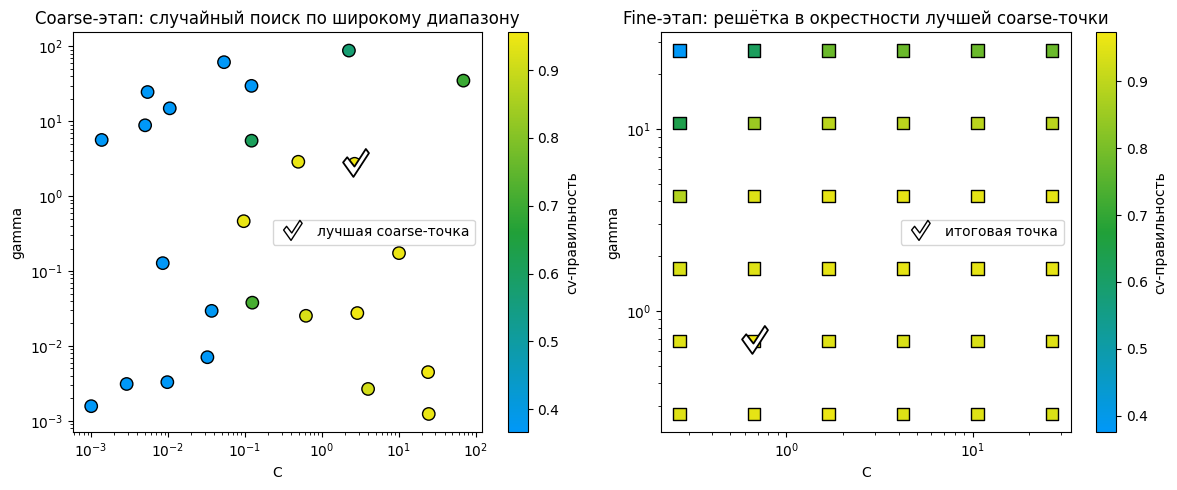

Лучшая точка после coarse-этапа:  C=2.667, gamma=2.707, score=0.956
Лучшая точка после fine-этапа:    C=0.67, gamma=0.68, score=0.973


In [11]:
def _quality(C, gamma):
    return cross_val_score(SVC(C=C, gamma=gamma), X_train, y_train, cv=3).mean()

rng = np.random.RandomState(1)
n_coarse = 25
coarse_C = 10 ** rng.uniform(-3, 2, n_coarse)
coarse_gamma = 10 ** rng.uniform(-3, 2, n_coarse)
coarse_scores = np.array([_quality(c, g) for c, g in zip(coarse_C, coarse_gamma)])

best_i = np.argmax(coarse_scores)
best_C, best_gamma = coarse_C[best_i], coarse_gamma[best_i]

span = 0.4  # доля от диапазона (в log10-масштабе), задающая "окрестность"
log_span = span * (2 - (-3))
fine_C = np.logspace(np.log10(best_C) - log_span / 2, np.log10(best_C) + log_span / 2, 6)
fine_gamma = np.logspace(np.log10(best_gamma) - log_span / 2, np.log10(best_gamma) + log_span / 2, 6)
fine_grid_C, fine_grid_gamma = np.meshgrid(fine_C, fine_gamma)
fine_scores = np.array([_quality(c, g) for c, g in
                         zip(fine_grid_C.ravel(), fine_grid_gamma.ravel())])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(coarse_C, coarse_gamma, c=coarse_scores, cmap=ss.CMAP, s=80,
                       edgecolor="black")
axes[0].scatter([best_C], [best_gamma], marker=ss.CHECK_MARKER, s=500,
                c=ss.WHITE, edgecolor="black", linewidth=1.3,
                label="лучшая coarse-точка")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("C"); axes[0].set_ylabel("gamma")
axes[0].set_title("Coarse-этап: случайный поиск по широкому диапазону")
axes[0].legend(handles=[ss.check_legend_handle(
    label="лучшая coarse-точка", color=ss.WHITE)])
fig.colorbar(sc0, ax=axes[0], label="cv-правильность")

sc1 = axes[1].scatter(fine_grid_C.ravel(), fine_grid_gamma.ravel(), c=fine_scores,
                       cmap=ss.CMAP, s=80, edgecolor="black", marker="s")
best_fine_i = np.argmax(fine_scores)
axes[1].scatter([fine_grid_C.ravel()[best_fine_i]], [fine_grid_gamma.ravel()[best_fine_i]],
                marker=ss.CHECK_MARKER, s=500, c=ss.WHITE,
                edgecolor="black", linewidth=1.3, label="итоговая точка")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("C"); axes[1].set_ylabel("gamma")
axes[1].set_title("Fine-этап: решётка в окрестности лучшей coarse-точки")
axes[1].legend(handles=[ss.check_legend_handle(
    label="итоговая точка", color=ss.WHITE)])
fig.colorbar(sc1, ax=axes[1], label="cv-правильность")

plt.tight_layout()
plt.show()

print("Лучшая точка после coarse-этапа:  C={:.4g}, gamma={:.4g}, score={:.3f}".format(
    best_C, best_gamma, coarse_scores[best_i]))
print("Лучшая точка после fine-этапа:    C={:.4g}, gamma={:.4g}, score={:.3f}".format(
    fine_grid_C.ravel()[best_fine_i], fine_grid_gamma.ravel()[best_fine_i], fine_scores[best_fine_i]))

### Собственный класс `CoarseToFineSearchCV`

Реализуем описанную логику как полноценный scikit-learn совместимый
поисковик гиперпараметров, наследуясь от абстрактного класса
`sklearn.model_selection._search.BaseSearchCV` — того же базового
класса, от которого наследуются `GridSearchCV` и `RandomizedSearchCV`.
Всё, что требуется от наследника — реализовать метод `_run_search`,
который получает на вход колбэк `evaluate_candidates` (обучает и
оценивает переданный список комбинаций параметров по кросс-валидации
и накапливает результаты в `cv_results_`) и сам решает, *какие*
комбинации и в каком порядке ему передавать.

Важное отличие от первой версии класса: вместо того чтобы вручную
писать цикл сэмплирования случайных точек, реализация **напрямую
переиспользует внутренние строительные блоки** самих `RandomizedSearchCV`
и `GridSearchCV`:

* на **coarse**-этапе кандидаты генерируются точно так же, как это
  делает `RandomizedSearchCV` — через `sklearn.model_selection.
  ParameterSampler` (числовые диапазоны `(low, high)` автоматически
  оборачиваются в `scipy.stats.loguniform`/`scipy.stats.uniform` в
  зависимости от того, насколько широк диапазон — как и раньше, но
  теперь семплирование выполняет сам `ParameterSampler`, а не
  самописный цикл со случайными числами);
* на **fine**-этапе кандидаты генерируются точно так же, как это
  делает `GridSearchCV` — через `sklearn.model_selection.ParameterGrid`
  по локальной сетке вокруг лучшей coarse-точки.

Такой подход надёжнее самописного: `ParameterSampler` уже умеет
корректно работать с произвольными scipy-распределениями и списками
значений (в том числе теми, что пользователь передаст сам), а не
только с той парой случаев (`uniform`/`loguniform`), которую было бы
легко реализовать вручную.

Наша реализация вызывает `evaluate_candidates` дважды — с результатом
`ParameterSampler(..., n_iter=n_coarse_iter)` на coarse-этапе и с
результатом `ParameterGrid(...)` на fine-этапе. После `_run_search`
базовый класс сам агрегирует результаты обоих этапов в `cv_results_` и
выбирает `best_params_`/`best_score_`/`best_estimator_` по всем
оценённым кандидатам сразу (обычно "побеждает" одна из точек
fine-этапа, так как она находится в уже разведанной перспективной
области).

Проверим класс на той же задаче SVC на `digits`, что и в разделе
3, и сравним итог с coarse-этапом.

In [12]:
digits_X_train, digits_X_test, digits_y_train, digits_y_test = train_test_split(
    digits.data, digits.target, random_state=0)

param_distributions = {"C": (1e-2, 1e2), "gamma": (1e-4, 1e0)}

ctf_search = CoarseToFineSearchCV(
    SVC(), param_distributions,
    n_coarse_iter=20, fine_grid_points=5, fine_neighborhood=0.3,
    cv=5, random_state=0)
ctf_search.fit(digits_X_train, digits_y_train)

print("После coarse-этапа: params={}, cv-score={:.4f}".format(
    ctf_search.coarse_best_params_, ctf_search.coarse_best_score_))
print("Итоговые (fine) параметры: params={}, cv-score={:.4f}".format(
    ctf_search.best_params_, ctf_search.best_score_))
print("Правильность на тестовой выборке: {:.4f}".format(
    ctf_search.score(digits_X_test, digits_y_test)))
print("Всего оценено комбинаций: {} (coarse: {} + fine: {})".format(
    len(ctf_search.cv_results_["params"]), 20,
    len(ctf_search.cv_results_["params"]) - 20))

После coarse-этапа: params={'C': 71.55682161754872, 'gamma': 0.0034179529120610124}, cv-score=0.9852
Итоговые (fine) параметры: params={'C': np.float64(56.55832161754872), 'gamma': np.float64(0.0001)}, cv-score=0.9881
Правильность на тестовой выборке: 0.9844
Всего оценено комбинаций: 45 (coarse: 20 + fine: 25)


`CoarseToFineSearchCV` полностью совместим с интерфейсом
scikit-learn: после `fit` доступны `best_params_`, `best_score_`,
`best_estimator_`, `cv_results_` (как у `GridSearchCV`), а сам объект
можно использовать как обычную модель — вызывать `.predict()`,
`.score()`, встраивать в `Pipeline`, передавать в `cross_val_score` для
вложенной кросс-валидации и т.д.

### Итоги ноутбука

* Кросс-валидация даёт более надёжную оценку качества модели, чем
  единственный `train_test_split`, ценой дополнительных вычислений — и
  является обязательным строительным блоком для честного подбора
  гиперпараметров.
* Выбор *вида* кросс-валидации должен учитывать структуру данных:
  порядок/сортировку (`shuffle`), баланс классов (`Stratified*`),
  зависимость объектов друг от друга (`GroupKFold`), временную природу
  (`TimeSeriesSplit`).
* Подбор гиперпараметров — это тоже часть процесса обучения модели, и
  тестовую выборку нельзя использовать для его выполнения: для этого
  существуют `GridSearchCV`, `RandomizedSearchCV`, Successive Halving и
  их комбинации, включая эвристику coarse-to-fine.
* Прежде чем доверять результатам кросс-валидации на новых
  ("боевых") данных, полезно явно проверить репрезентативность выборки
  с помощью adversarial validation.